## smote过采样

100%|██████████| 10/10 [00:03<00:00,  3.00it/s]


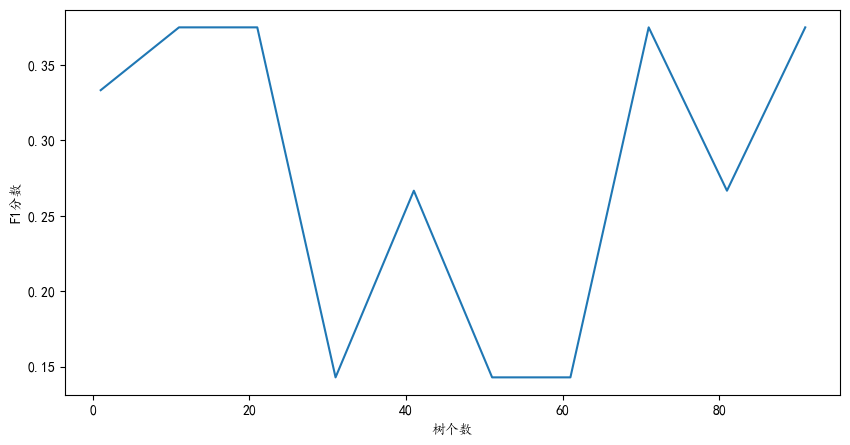

In [1]:
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import trange

data_train = pd.read_excel('D:\服务创业\新代码\sofm_train0.xlsx')
data_test = pd.read_excel('D:\服务创业\新代码\sofm_test0.xlsx')
X_train = data_train.iloc[:, :-1]
y_train = data_train.iloc[:, -1]
X_test = data_test.iloc[:, :-1]
y_test = data_test.iloc[:, -1]

scores = []
for i in trange(1, 101, 10):
        rfc = RFC(n_estimators=i, random_state=100
                #   ,max_depth=40, min_samples_split = i
                )
        rfc.fit(X_train, y_train)
        y_pre = rfc.predict(X_test)
        score = f1_score(y_test,y_pre)
        # score
        scores.append(score)
        
plt.rcParams['font.family'] = 'KaiTi'
plt.figure(figsize=[10, 5])
plt.plot(list(range(1,101,10)), scores)
plt.xlabel("树个数")
plt.ylabel("F1分数")
plt.show()

## RUSBoost欠采样

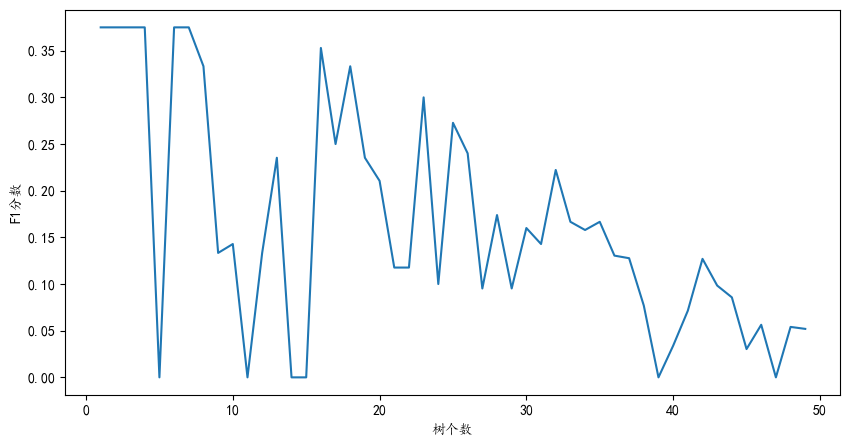

最大F1分数为0.375，采样比例为1


In [4]:
from sklearn.ensemble import AdaBoostClassifier as AdBoost
from imblearn.under_sampling import RandomUnderSampler as RUS
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
from imblearn.under_sampling import EditedNearestNeighbours
import warnings
import numpy as np
# 忽略所有警告
warnings.filterwarnings("ignore")

# 在这里编写你的代码，所有警告将被忽略
scores = []
ori_data = pd.read_excel('D:\服务创业\新代码\sofm_train0.xlsx')
X_ori = ori_data.iloc[:, :-1]
y_ori = ori_data.iloc[:, -1]
max_i=0
max_f1=0
for i in range(1, 50, 1):
    
    enn = EditedNearestNeighbours(n_neighbors=i)
    X_resampled, y_resampled = enn.fit_resample(X_ori, y_ori)
    rfc = RFC(n_estimators=100, random_state=100  # , max_depth=50
                  #   ,min_samples_leaf=1
                  #   ,min_samples_split=2
                  )
    rfc.fit(X_resampled, y_resampled)
    y_pre = rfc.predict(X_test)
    score = f1_score(y_test, y_pre)
    scores.append(score)
    if score>max_f1:
        max_f1=score
        max_i=i
plt.rcParams['font.family'] = 'KaiTi'
plt.figure(figsize=[10, 5])
plt.plot(list(np.arange(1, 50, 1)), scores)
plt.xlabel("树个数")
plt.ylabel("F1分数")
plt.show()
print(f'最大F1分数为{max_f1}，采样比例为{max_i}')

In [9]:
rus = RUS(sampling_strategy=0.17, replacement=True, random_state=100)
X_resampled, y_resampled = rus.fit_resample(X_ori, y_ori)
rus_data = pd.concat([X_resampled, y_resampled], axis=1)
rus_data.to_excel('D:\服务创业\新代码\sofm0_train_rus.xlsx', index=False)